# Massachusetts Accrual Win walkthrough

## 1. Objective and decision being tested

This notebook tests whether Massachusetts **Accrual Win by Licensee** can safely populate the existing `gross_revenue` column **without replacing** the currently stored handle, taxable revenue, or tax.

**Current collector behavior.** The production Massachusetts parser already reads four money values around the published Hold % on each Category 3 online operator row. It keeps:

1. Current & Future Wagers Settled → `handle`
2. *(discarded)* Accrual Win by Licensee
3. Taxable Gaming Revenue → `taxable_revenue`
4. Tax Collected → `tax`

`gross_revenue` is written as `NULL` for every MA sportsbook row.

**Decision under test.** Map Accrual Win to `gross_revenue` and leave the other three fields unchanged. This is enrichment, not replacement.

**Hard rule.** `gross_revenue` and `taxable_revenue` describe different official columns. They must remain separate. They are not interchangeable with GGR, AGR, or net proceeds from other states.

**This notebook does not:** change `massachusetts.py`, write to SQLite, download reports, or create a production metric-contract file.

Official context (recorded here; the notebook runs offline):

- Current reports: https://massgaming.com/regulations/revenue/
- Historical archive: https://massgaming.com/regulations/revenue/revenue-report-archives/

MGC publishes monthly reports and notes that operators may update historical figures. Revisions and point-in-time limits are assessed later; they are not ignored.


## 2. Reproducible read-only setup

**What.** Open the promoted production database with a URI `mode=ro` connection, hash the file, and inventory the local MA raw folder.

**Why.** Methodology work must not mutate retained observations. The hash is recorded before and after execution.

**Assumptions.** The current local snapshot is the approved post-NJ-repair database. Raw MA PDFs already exist under `data/raw/MA`.

**Inspect.** Repository root, Python/package versions, Git HEAD, database path/hash, URI, raw PDF count.


In [1]:
from __future__ import annotations

import hashlib
import re
import sqlite3
import subprocess
import sys
from decimal import Decimal, ROUND_HALF_EVEN
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import pdfplumber

ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from variant_gaming.common import month_period, parse_money, project_root, sha256_bytes
from variant_gaming.states.massachusetts import (
    INLINE_ROW_RE,
    MONEY_FIELD,
    MONEY_ROW_RE,
    PRE_LAUNCH_EMPTY_OK,
    RETAIL_OPERATORS,
    SKIP_LABELS,
    find_online_operator_text,
    parse_report_period,
)
from variant_gaming.storage import default_db_path

ROOT = project_root()
DATABASE_PATH = default_db_path(ROOT)
EXPECTED_DB_HASH = "327799CA20D9A31FE664F489E5BBC98D930D0A3C08B786F849E4E746FDC3FDB6"
RAW_MA = ROOT / "data" / "raw" / "MA"
FIXTURE_MARCH = ROOT / "tests" / "fixtures" / "MA" / "March-Rev-Report.pdf"
FIXTURE_JULY = ROOT / "tests" / "fixtures" / "MA" / "MGC-Revenue-Report-July-2026.pdf"


def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def git_head() -> str:
    try:
        return subprocess.check_output(["git", "rev-parse", "HEAD"], cwd=ROOT, text=True).strip()
    except (OSError, subprocess.CalledProcessError):
        return "unavailable"


DB_HASH_BEFORE = sha256_file(DATABASE_PATH)
print("Repository root:", ROOT)
print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("pdfplumber:", pdfplumber.__version__)
print("Git HEAD:", git_head())
print("Database:", DATABASE_PATH)
print("Database hash (before):", DB_HASH_BEFORE)
assert DB_HASH_BEFORE.lower() == EXPECTED_DB_HASH.lower()

DB_URI = f"file:{DATABASE_PATH.as_posix()}?mode=ro"
connection = sqlite3.connect(DB_URI, uri=True)
print("Connection URI:", DB_URI)
assert "mode=ro" in DB_URI

integrity = connection.execute("PRAGMA integrity_check").fetchone()[0]
print("PRAGMA integrity_check:", integrity)
assert integrity == "ok"

pdfs = sorted(RAW_MA.rglob("*.pdf"))
print("Raw MA directory:", RAW_MA)
print("Retained PDF count:", len(pdfs))
assert len(pdfs) == 42



Repository root: C:\Users\Sean\VscProjects\researchOS
Python: 3.11.9
pandas: 3.0.5
pdfplumber: 0.11.10
Git HEAD: 8b17327005dbe05fc637fb5c812b481434b99427
Database: C:\Users\Sean\VscProjects\researchOS\data\gaming.sqlite
Database hash (before): 327799ca20d9a31fe664f489e5bbc98d930d0a3c08b786f849e4e746fdc3fdb6
Connection URI: file:C:/Users/Sean/VscProjects/researchOS/data/gaming.sqlite?mode=ro
PRAGMA integrity_check: ok
Raw MA directory: C:\Users\Sean\VscProjects\researchOS\data\raw\MA
Retained PDF count: 42


## 3. Inspect current normalized MA data

**What.** Read every Massachusetts `online_sports_betting` row already stored in SQLite.

**Why.** The enrichment claim is only valid if today's rows already have handle, taxable revenue, and tax — and if `gross_revenue` is entirely NULL.

**Assumptions.** One current observation per operator-month after collector ingest. We do not coalesce revenue bases.

**Inspect.** Shape, dtypes, missingness, operators, period span, business-key duplicates, and non-null counts for the four money fields.


In [2]:
ma = pd.read_sql_query(
    """
    SELECT * FROM gaming_results
    WHERE state_code = 'MA' AND vertical = 'online_sports_betting'
    ORDER BY period_start, operator
    """,
    connection,
)
print("shape:", ma.shape)
display(ma.dtypes.to_frame("dtype"))
display(ma.head(5))
display(ma.isna().mean().sort_values(ascending=False).to_frame("missing_rate"))

print("frequencies:", sorted(ma["frequency"].dropna().unique()))
print("channels:", sorted(ma["channel"].dropna().unique()))
print("row_types:", sorted(ma["row_type"].dropna().unique()))
print("period_start:", ma["period_start"].min(), "→", ma["period_start"].max())
print("distinct months:", ma["period_start"].nunique())
print("operators:")
display(ma["operator"].value_counts().to_frame("rows"))

biz = ["state_code", "vertical", "channel", "operator", "period_start"]
dupes = ma.groupby(biz).size().reset_index(name="n")
print("duplicate business keys:", int((dupes["n"] > 1).sum()))

print("non-null money fields")
display(
    pd.Series(
        {
            "handle": int(ma["handle"].notna().sum()),
            "gross_revenue": int(ma["gross_revenue"].notna().sum()),
            "taxable_revenue": int(ma["taxable_revenue"].notna().sum()),
            "tax": int(ma["tax"].notna().sum()),
        },
        name="non_null_rows",
    ).to_frame()
)

assert len(ma) == 291
assert ma["period_start"].nunique() == 41
assert ma["operator"].nunique() == 13
assert ma["handle"].notna().all()
assert ma["taxable_revenue"].notna().all()
assert ma["tax"].notna().all()
assert ma["gross_revenue"].isna().all()
print("Current MA gross_revenue is entirely NULL.")
display(ma[["source_file", "source_sha256", "retrieved_at_utc"]].drop_duplicates().head(5))



shape: (291, 21)


,dtype
jurisdiction,str
state_code,str
vertical,str
channel,str
operator,str
row_type,str
period_start,str
period_end,str
frequency,str
handle,float64


,jurisdiction,state_code,vertical,channel,operator,row_type,period_start,period_end,frequency,handle,...,adjusted_revenue,taxable_revenue,net_proceeds,tax,reported_revenue_name,source_url,source_file,source_sha256,retrieved_at_utc,report_status
0,Massachusetts,MA,online_sports_betting,online,Barstool Sportsbook,operator,2023-03-01,2023-03-31,monthly,2.950572e+07,...,None,2893576.49,None,578715.30,Taxable Gaming Revenue,https://massgaming.com/wp-content/uploads/Marc...,data/raw/MA/2026-09-03/070b1b066c0dbedfeb302fb...,070b1b066c0dbedfeb302fb7293748a42a1d926bf96b70...,2026-09-03T02:38:16.663668+00:00,ok
1,Massachusetts,MA,online_sports_betting,online,BetMGM,operator,2023-03-01,2023-03-31,monthly,4.527118e+07,...,None,7314463.61,None,1462892.72,Taxable Gaming Revenue,https://massgaming.com/wp-content/uploads/Marc...,data/raw/MA/2026-09-03/070b1b066c0dbedfeb302fb...,070b1b066c0dbedfeb302fb7293748a42a1d926bf96b70...,2026-09-03T02:38:16.663668+00:00,ok
2,Massachusetts,MA,online_sports_betting,online,Caesars Sportsbook,operator,2023-03-01,2023-03-31,monthly,1.639840e+07,...,None,1814141.90,None,362828.38,Taxable Gaming Revenue,https://massgaming.com/wp-content/uploads/Marc...,data/raw/MA/2026-09-03/070b1b066c0dbedfeb302fb...,070b1b066c0dbedfeb302fb7293748a42a1d926bf96b70...,2026-09-03T02:38:16.663668+00:00,ok
3,Massachusetts,MA,online_sports_betting,online,DraftKings,operator,2023-03-01,2023-03-31,monthly,2.576343e+08,...,None,15556827.40,None,3111365.49,Taxable Gaming Revenue,https://massgaming.com/wp-content/uploads/Marc...,data/raw/MA/2026-09-03/070b1b066c0dbedfeb302fb...,070b1b066c0dbedfeb302fb7293748a42a1d926bf96b70...,2026-09-03T02:38:16.663668+00:00,ok
4,Massachusetts,MA,online_sports_betting,online,FanDuel,operator,2023-03-01,2023-03-31,monthly,1.810852e+08,...,None,16002999.72,None,3200599.94,Taxable Gaming Revenue,https://massgaming.com/wp-content/uploads/Marc...,data/raw/MA/2026-09-03/070b1b066c0dbedfeb302fb...,070b1b066c0dbedfeb302fb7293748a42a1d926bf96b70...,2026-09-03T02:38:16.663668+00:00,ok


,missing_rate
adjusted_revenue,1.0
gross_revenue,1.0
net_proceeds,1.0
state_code,0.0
jurisdiction,0.0
operator,0.0
channel,0.0
vertical,0.0
row_type,0.0
frequency,0.0


frequencies: ['monthly']
channels: ['online']
row_types: ['operator']
period_start: 2023-03-01 → 2026-07-01
distinct months: 41
operators:


,rows
operator,
BetMGM,41
Caesars Sportsbook,41
DraftKings,41
FanDuel,41
Fanatics,39
Bally Bet,25
ESPN Bet,24
WynnBet,12
Betr,10


duplicate business keys: 0
non-null money fields


,non_null_rows
handle,291
gross_revenue,0
taxable_revenue,291
tax,291


Current MA gross_revenue is entirely NULL.


,source_file,source_sha256,retrieved_at_utc
0,data/raw/MA/2026-09-03/070b1b066c0dbedfeb302fb...,070b1b066c0dbedfeb302fb7293748a42a1d926bf96b70...,2026-09-03T02:38:16.663668+00:00
6,data/raw/MA/2026-09-03/996011b86b5f12397b413d1...,996011b86b5f12397b413d1f5fc9ae1c5e3289742138a3...,2026-09-03T02:38:16.663668+00:00
12,data/raw/MA/2026-09-03/bf21d2b5603ee3434853af5...,bf21d2b5603ee3434853af5de7d7045eec4ccb95ead0a6...,2026-09-03T02:38:16.663668+00:00
20,data/raw/MA/2026-09-03/9a71b89e76df84a8f88cbbb...,9a71b89e76df84a8f88cbbb07a37a6d3eabc6d95f64b76...,2026-09-03T02:38:16.663668+00:00
28,data/raw/MA/2026-09-03/7269531f712f66beab5823b...,7269531f712f66beab5823b03efb5e5d93dead015b5ae1...,2026-09-03T02:38:16.663668+00:00


## 4. Inventory the retained source PDFs

**What.** Hash every file under `data/raw/MA`, compare the 64-character filename prefix to the calculated SHA-256, and parse the official report month from each PDF heading.

**Why.** Enrichment must replay the same retained files the collector already used — not a live download.

**Assumptions.** Filenames follow `{sha256}_{original-name}.pdf`. February 2023 is a pre-launch month and may have no online operator rows.

**Inspect.** 42 unique hashes, filename/hash agreement, and a continuous source-month sequence from February 2023 through July 2026.


In [3]:
def filename_hash_prefix(path: Path) -> str:
    return path.name.split("_", 1)[0].lower()


inventory_rows = []
for path in pdfs:
    content = path.read_bytes()
    digest = sha256_bytes(content)
    prefix = filename_hash_prefix(path)
    with pdfplumber.open(path) as pdf:
        full_text = "\n".join((page.extract_text() or "") for page in pdf.pages)
    year, month = parse_report_period(full_text)
    inventory_rows.append(
        {
            "source_path": str(path.relative_to(ROOT)).replace("\\", "/"),
            "file_size": path.stat().st_size,
            "sha256": digest,
            "filename_prefix": prefix,
            "hash_matches_filename": digest.lower() == prefix,
            "report_year": year,
            "report_month": month,
            "period_start": f"{year}-{month:02d}-01",
            "extraction_status": "heading_ok",
        }
    )

inventory = pd.DataFrame(inventory_rows).sort_values("period_start").reset_index(drop=True)
print("inventory shape:", inventory.shape)
display(inventory.head(3))
display(inventory.iloc[[len(inventory) // 2]])
display(inventory.tail(3))

assert len(inventory) == 42
assert inventory["sha256"].is_unique
assert inventory["hash_matches_filename"].all()

expected_months = pd.date_range("2023-02-01", "2026-07-01", freq="MS")
actual_months = pd.to_datetime(inventory["period_start"])
assert sorted(actual_months) == list(expected_months), "source-month coverage mismatch"
assert actual_months.nunique() == 42
print("42 unique source months, February 2023 through July 2026, no duplicates.")



inventory shape: (42, 9)


,source_path,file_size,sha256,filename_prefix,hash_matches_filename,report_year,report_month,period_start,extraction_status
0,data/raw/MA/2026-09-03/788ba3f15943b47db277699...,617350,788ba3f15943b47db277699f8302181e14c7c0f3abb6c2...,788ba3f15943b47db277699f8302181e14c7c0f3abb6c2...,True,2023,2,2023-02-01,heading_ok
1,data/raw/MA/2026-09-03/070b1b066c0dbedfeb302fb...,670771,070b1b066c0dbedfeb302fb7293748a42a1d926bf96b70...,070b1b066c0dbedfeb302fb7293748a42a1d926bf96b70...,True,2023,3,2023-03-01,heading_ok
2,data/raw/MA/2026-09-03/996011b86b5f12397b413d1...,2215252,996011b86b5f12397b413d1f5fc9ae1c5e3289742138a3...,996011b86b5f12397b413d1f5fc9ae1c5e3289742138a3...,True,2023,4,2023-04-01,heading_ok


,source_path,file_size,sha256,filename_prefix,hash_matches_filename,report_year,report_month,period_start,extraction_status
21,data/raw/MA/2026-09-03/0bc7b883d90c9439b1ab664...,365800,0bc7b883d90c9439b1ab6641c43f2dd015d95b29e7f40f...,0bc7b883d90c9439b1ab6641c43f2dd015d95b29e7f40f...,True,2024,11,2024-11-01,heading_ok


,source_path,file_size,sha256,filename_prefix,hash_matches_filename,report_year,report_month,period_start,extraction_status
39,data/raw/MA/2026-09-03/a6f57e1571017921d1a11fa...,322100,a6f57e1571017921d1a11fa6987fbcd98c774bc556eafc...,a6f57e1571017921d1a11fa6987fbcd98c774bc556eafc...,True,2026,5,2026-05-01,heading_ok
40,data/raw/MA/2026-09-03/6d2e3ac63934f1d6169a886...,318112,6d2e3ac63934f1d6169a8861749b85749250873d98e8c6...,6d2e3ac63934f1d6169a8861749b85749250873d98e8c6...,True,2026,6,2026-06-01,heading_ok
41,data/raw/MA/2026-09-03/ccac154845a1a2e63dac0a3...,738628,ccac154845a1a2e63dac0a33a9d725edf6eeaa2f203736...,ccac154845a1a2e63dac0a33a9d725edf6eeaa2f203736...,True,2026,7,2026-07-01,heading_ok


42 unique source months, February 2023 through July 2026, no duplicates.


## 5. Show raw text before transformation

**What.** Print the official ONLINE LICENSEE block from the two fixture PDFs, including the header, several operator rows, and the Total Online control row.

**Why.** The mapping is positional. Seeing the four money tokens around Hold % is the evidence; a pre-normalized table is not.

**Assumptions.** pdfplumber text order matches the published table: Wagers Settled, Accrual Win, Hold %, Taxable Gaming Revenue, Tax Collected.

**Inspect.** Two-line layout (money row, then operator name) used by both March 2023 and July 2026 fixtures. The existing parser already recognizes this layout and an inline one-line variant.


In [4]:
def online_block(path: Path) -> str:
    with pdfplumber.open(path) as pdf:
        return find_online_operator_text(pdf)


def preview_online_lines(text: str, after: int = 22) -> pd.DataFrame:
    lines = [ln.strip() for ln in text.splitlines() if ln.strip()]
    start = next(i for i, ln in enumerate(lines) if ln.upper() == "ONLINE LICENSEE")
    snippet = lines[start : start + after]
    return pd.DataFrame({"line_no": range(start, start + len(snippet)), "text": snippet})


print("March 2023 fixture — raw ONLINE LICENSEE lines")
display(preview_online_lines(online_block(FIXTURE_MARCH)))
print("July 2026 fixture — raw ONLINE LICENSEE lines")
display(preview_online_lines(online_block(FIXTURE_JULY)))
print(
    "Positional mapping on a money row:\n"
    "  token 1 → Current & Future Wagers Settled (handle)\n"
    "  token 2 → Accrual Win by Licensee (proposed gross_revenue)\n"
    "  Hold %  → published hold, used only for validation\n"
    "  token 3 → Taxable Gaming Revenue (taxable_revenue)\n"
    "  token 4 → Tax Collected (tax)"
)



March 2023 fixture — raw ONLINE LICENSEE lines


,line_no,text
0,2,ONLINE LICENSEE
1,3,Wagers Settled by Licensee Hold % Gaming Reven...
2,4,"$29,505,722.12 $2,969,195.70 10.06% $2,893,576..."
3,5,Barstool Sportsbook
4,6,"$45,271,182.54 $7,427,641.00 16.41% $7,314,463..."
5,7,BetMGM
6,8,"$16,398,404.60 $1,855,139.90 11.31% $1,814,141..."
7,9,Caesars Sportsbook
8,10,"$257,634,288.50 $16,119,770.77 6.26% $15,556,8..."
9,11,DraftKings


July 2026 fixture — raw ONLINE LICENSEE lines


,line_no,text
0,2,ONLINE LICENSEE
1,3,Wagers Settled by Licensee Hold % Gaming Reven...
2,4,"$3,272,045.97 $392,145.69 11.98% $383,965.58 $..."
3,5,Bally Bet
4,6,"$52,791,146.49 $6,518,544.14 12.35% $6,386,566..."
5,7,BetMGM
6,8,"$17,603,582.28 $1,173,632.04 6.67% $1,129,965...."
7,9,Caesars Sportsbook
8,10,"$281,176,332.44 $33,004,446.68 11.74% $32,324,..."
9,11,DraftKings


Positional mapping on a money row:
  token 1 → Current & Future Wagers Settled (handle)
  token 2 → Accrual Win by Licensee (proposed gross_revenue)
  Hold %  → published hold, used only for validation
  token 3 → Taxable Gaming Revenue (taxable_revenue)
  token 4 → Tax Collected (tax)


## 6. Prototype the minimal enriched row parsing

**What.** Reuse the production regular expressions and skip lists. Keep the second money token instead of discarding it, and retain the published Hold %.

**Why.** The production change, if later approved, should be this small: do not invent a second parser.

**Assumptions.** Retail operators, Total Retail / Total Online / Total, and header labels remain excluded. February 2023 may emit zero online rows.

**Inspect.** Operator dictionaries now contain `wagers_settled`, `accrual_win`, `taxable_revenue`, `tax_collected`, and `hold_pct`.


In [5]:
def parse_hold_pct(token: str) -> float:
    return float(token.replace("%", "").strip())


def enriched_amounts_from_money_row(line: str) -> dict | None:
    match = MONEY_ROW_RE.match(line)
    if not match:
        return None
    tokens = re.findall(MONEY_FIELD, line)
    values = [parse_money(token) for token in tokens]
    if len(values) != 4 or any(v is None for v in values):
        return None
    return {
        "wagers_settled": values[0],
        "accrual_win": values[1],
        "hold_pct": parse_hold_pct(match.group("hold")),
        "taxable_revenue": values[2],
        "tax_collected": values[3],
    }


def enriched_inline_row(line: str) -> tuple[str, dict] | None:
    match = INLINE_ROW_RE.match(line.strip())
    if not match:
        return None
    amounts = enriched_amounts_from_money_row(line[match.end("operator") :].strip())
    if amounts is None:
        tokens = re.findall(MONEY_FIELD, line)
        values = [parse_money(token) for token in tokens]
        if len(values) != 4 or any(v is None for v in values):
            return None
        amounts = {
            "wagers_settled": values[0],
            "accrual_win": values[1],
            "hold_pct": parse_hold_pct(match.group("hold")),
            "taxable_revenue": values[2],
            "tax_collected": values[3],
        }
    operator = match.group("operator").strip()
    return operator, amounts


def parse_online_section_enriched(text: str) -> tuple[list[dict], dict | None]:
    lines = [line.strip() for line in text.splitlines() if line.strip()]
    in_online = False
    operators: list[dict] = []
    total_online: dict | None = None
    idx = 0
    while idx < len(lines):
        line = lines[idx]
        if line.upper() == "ONLINE LICENSEE":
            in_online = True
            idx += 1
            continue
        if not in_online:
            idx += 1
            continue
        if line.lower() == "total" and idx > 0:
            amounts = enriched_amounts_from_money_row(lines[idx - 1])
            if amounts is not None:
                total_online = amounts
            break

        inline = enriched_inline_row(line)
        if inline is not None:
            operator, amounts = inline
            if operator not in RETAIL_OPERATORS and operator not in SKIP_LABELS:
                operators.append({"operator": operator, **amounts})
            idx += 1
            continue

        amounts = enriched_amounts_from_money_row(line)
        if amounts is not None and idx + 1 < len(lines):
            operator = lines[idx + 1]
            if operator in RETAIL_OPERATORS or operator in SKIP_LABELS or operator.lower() == "total":
                idx += 1
                continue
            operators.append({"operator": operator, **amounts})
            idx += 2
            continue
        idx += 1
    return operators, total_online


def parse_revenue_pdf_enriched(content: bytes) -> tuple[list[dict], dict | None, tuple[int, int]]:
    with pdfplumber.open(path_or_bytes(content)) as pdf:
        full_text = "\n".join((page.extract_text() or "") for page in pdf.pages)
        online_text = find_online_operator_text(pdf)
    year, month = parse_report_period(full_text)
    allow_empty = (year, month) == PRE_LAUNCH_EMPTY_OK
    if not online_text:
        if allow_empty:
            return [], None, (year, month)
        raise ValueError(f"Missing ONLINE LICENSEE section for {year}-{month:02d}")
    operators, total_online = parse_online_section_enriched(online_text)
    if not operators:
        if allow_empty:
            return [], total_online, (year, month)
        raise ValueError(f"No Category 3 online operators parsed for {year}-{month:02d}")
    if total_online is None:
        raise ValueError(f"Missing Total Online control row for {year}-{month:02d}")
    return operators, total_online, (year, month)


def path_or_bytes(content: bytes):
    from io import BytesIO
    return BytesIO(content)


print("Prototype keeps four money fields plus published hold_pct.")
print("Existing skip rules unchanged: retail, totals, header labels.")



Prototype keeps four money fields plus published hold_pct.
Existing skip rules unchanged: retail, totals, header labels.


## 7. Exact fixture checks

**What.** Parse the two official fixture PDFs with the prototype and assert published totals plus DraftKings July 2026.

**Why.** These values are already used as production parser gates for handle/taxable/tax. Accrual Win must join that gate, not replace it.

**Assumptions.** Fixture bytes are the same reports used by `tests/test_massachusetts_pdf_fixtures.py`. Negatives, if present, stay negative.

**Inspect.** Operator counts (6 / 7) and the official Total Online money row.


In [6]:
def money_eq(actual, expected, tol: str = "0.01") -> bool:
    return abs(Decimal(str(actual)) - Decimal(str(expected))) <= Decimal(tol)


march_ops, march_total, march_period = parse_revenue_pdf_enriched(FIXTURE_MARCH.read_bytes())
assert march_period == (2023, 3)
assert len(march_ops) == 6
assert money_eq(march_total["wagers_settled"], 548_102_467.42)
assert money_eq(march_total["accrual_win"], 46_783_507.41)
assert money_eq(march_total["taxable_revenue"], 45_605_606.69)
assert money_eq(march_total["tax_collected"], 9_121_121.34)
print("March 2023 fixture totals OK; operators:", [op["operator"] for op in march_ops])

july_ops, july_total, july_period = parse_revenue_pdf_enriched(FIXTURE_JULY.read_bytes())
assert july_period == (2026, 7)
assert len(july_ops) == 7
assert money_eq(july_total["wagers_settled"], 587_101_900.84)
assert money_eq(july_total["accrual_win"], 66_530_607.93)
assert money_eq(july_total["taxable_revenue"], 65_101_989.55)
assert money_eq(july_total["tax_collected"], 13_020_397.81)
dk = next(op for op in july_ops if op["operator"] == "DraftKings")
assert money_eq(dk["wagers_settled"], 281_176_332.44)
assert money_eq(dk["accrual_win"], 33_004_446.68)
assert money_eq(dk["taxable_revenue"], 32_324_402.68)
assert money_eq(dk["tax_collected"], 6_464_880.54)
print("July 2026 fixture totals and DraftKings OK.")
display(pd.DataFrame(july_ops))



March 2023 fixture totals OK; operators: ['Barstool Sportsbook', 'BetMGM', 'Caesars Sportsbook', 'DraftKings', 'FanDuel', 'WynnBet']


July 2026 fixture totals and DraftKings OK.


,operator,wagers_settled,accrual_win,hold_pct,taxable_revenue,tax_collected
0,Bally Bet,3.272046e+06,392145.69,11.98,383965.58,76793.12
1,BetMGM,5.279115e+07,6518544.14,12.35,6386566.27,1277313.25
2,Caesars Sportsbook,1.760358e+07,1173632.04,6.67,1129965.58,225993.01
3,DraftKings,2.811763e+08,33004446.68,11.74,32324402.68,6464880.54
4,Fanatics,5.968206e+07,6599625.36,11.06,6453759.09,1290751.82
5,FanDuel,1.505948e+08,17165339.33,11.40,16801318.96,3360263.79
6,theScore Bet,2.198188e+07,1676874.69,7.63,1622011.39,324402.28


## 8. Replay the prototype across all retained PDFs

**What.** Parse every local MA PDF in memory. Fail closed on unexpected layouts.

**Why.** A fixture-only pass is not enough. The collector snapshot is 42 files.

**Assumptions.** February 2023 is the only pre-launch empty month. Every later report emits operator rows with all four money fields.

**Inspect.** 41 online months, 291 operator-month rows, March 2023–July 2026, no duplicate keys, no silent skips.


In [7]:
replay_frames = []
replay_totals = []
failed = []

for row in inventory.itertuples(index=False):
    path = ROOT / row.source_path
    try:
        operators, total_online, (year, month) = parse_revenue_pdf_enriched(path.read_bytes())
    except Exception as exc:  # noqa: BLE001
        failed.append({"source_path": row.source_path, "error": str(exc)})
        continue
    period_start, period_end = month_period(year, month)
    if (year, month) == PRE_LAUNCH_EMPTY_OK:
        assert operators == []
        replay_totals.append(
            {
                "period_start": period_start,
                "report_year": year,
                "report_month": month,
                "source_path": row.source_path,
                "source_sha256": row.sha256,
                "operator_count": 0,
                "pre_launch": True,
                **{k: None for k in ("wagers_settled", "accrual_win", "taxable_revenue", "tax_collected", "hold_pct")},
            }
        )
        continue
    if not operators or total_online is None:
        failed.append({"source_path": row.source_path, "error": "empty operators or missing total"})
        continue
    frame = pd.DataFrame(operators).assign(
        state_code="MA",
        vertical="online_sports_betting",
        channel="online",
        period_start=period_start,
        period_end=period_end,
        source_path=row.source_path,
        source_sha256=row.sha256,
    )
    required = ["wagers_settled", "accrual_win", "taxable_revenue", "tax_collected"]
    if frame[required].isna().any().any():
        failed.append({"source_path": row.source_path, "error": "null money field on an operator row"})
        continue
    replay_frames.append(frame)
    replay_totals.append(
        {
            "period_start": period_start,
            "report_year": year,
            "report_month": month,
            "source_path": row.source_path,
            "source_sha256": row.sha256,
            "operator_count": len(frame),
            "pre_launch": False,
            **total_online,
        }
    )

if failed:
    display(pd.DataFrame(failed))
    raise AssertionError(f"{len(failed)} retained PDF(s) failed; see table above")

prototype = pd.concat(replay_frames, ignore_index=True)
totals = pd.DataFrame(replay_totals).sort_values("period_start").reset_index(drop=True)
online_months = totals.loc[~totals["pre_launch"]]

print("PDFs reviewed:", len(inventory))
print("pre-launch months:", int(totals["pre_launch"].sum()))
print("online months:", len(online_months))
print("operator-month rows:", len(prototype))
print("period span:", prototype["period_start"].min(), "→", prototype["period_start"].max())

assert len(inventory) == 42
assert int(totals["pre_launch"].sum()) == 1
assert len(online_months) == 41
assert len(prototype) == 291
assert prototype["period_start"].min() == "2023-03-01"
assert prototype["period_start"].max() == "2026-07-01"
assert not prototype.duplicated(["operator", "period_start"]).any()
expected_online = pd.date_range("2023-03-01", "2026-07-01", freq="MS")
assert sorted(pd.to_datetime(prototype["period_start"].unique())) == list(expected_online)
assert prototype[["wagers_settled", "accrual_win", "taxable_revenue", "tax_collected"]].notna().all().all()
print("Replay gates passed.")
display(online_months[["period_start", "operator_count", "wagers_settled", "accrual_win", "taxable_revenue", "tax_collected"]].head(3))



PDFs reviewed: 42
pre-launch months: 1
online months: 41
operator-month rows: 291
period span: 2023-03-01 → 2026-07-01
Replay gates passed.


,period_start,operator_count,wagers_settled,accrual_win,taxable_revenue,tax_collected
1,2023-03-01,6,5.481025e+08,46783507.41,45605606.69,9121121.34
2,2023-04-01,6,5.662369e+08,59884578.33,58548295.26,11709653.81
3,2023-05-01,8,4.435597e+08,60484866.70,59410840.40,11882168.06


## 9. Total-row reconciliation

**What.** For each online report, compare the sum of operator rows to the official Total Online row.

**Why.** The production parser already fail-closes on handle/taxable/tax mismatches. Accrual Win needs the same control.

**Assumptions / tolerances (initial, not auto-loosened):**

- handle: $1.00 (already used in production; operator handle can sit up to $1 below the printed total)
- accrual win / taxable / tax: $0.01

Comparisons use `Decimal` quantized to cents.

**Inspect.** Maximum absolute difference per field. Any breach is displayed and stops the methodology as unresolved.


In [8]:
TOLERANCE = {
    "wagers_settled": Decimal("1.00"),
    "accrual_win": Decimal("0.01"),
    "taxable_revenue": Decimal("0.01"),
    "tax_collected": Decimal("0.01"),
}


def as_money(value) -> Decimal:
    return Decimal(str(value)).quantize(Decimal("0.01"), rounding=ROUND_HALF_EVEN)


recon_rows = []
breaches = []
for period, group in prototype.groupby("period_start"):
    official = totals.loc[totals["period_start"] == period].iloc[0]
    rec = {"period_start": period, "source_path": official["source_path"]}
    for field in TOLERANCE:
        op_sum = as_money(group[field].sum())
        off = as_money(official[field])
        diff = abs(op_sum - off)
        rec[f"{field}_operator_sum"] = float(op_sum)
        rec[f"{field}_official"] = float(off)
        rec[f"{field}_abs_diff"] = float(diff)
        if diff > TOLERANCE[field]:
            breaches.append({**rec, "field": field, "diff": float(diff), "tolerance": float(TOLERANCE[field])})
    recon_rows.append(rec)

recon = pd.DataFrame(recon_rows)
maxima = {
    field: float(recon[f"{field}_abs_diff"].max())
    for field in TOLERANCE
}
print("Maximum absolute operator-sum vs Total Online difference")
display(pd.Series(maxima, name="max_abs_diff").to_frame())

if breaches:
    display(pd.DataFrame(breaches))
    raise AssertionError("Reconciliation exceeded initial tolerances; methodology unresolved")

print("All 41 online reports reconcile within the initial tolerances.")



Maximum absolute operator-sum vs Total Online difference


,max_abs_diff
wagers_settled,0.90
accrual_win,0.00
taxable_revenue,0.01
tax_collected,0.00


All 41 online reports reconcile within the initial tolerances.


## 10. Hold validation

**What.** Compute `accrual_win / handle * 100` and compare it with the published Hold %.

**Why.** If Accrual Win is the economic numerator of the printed hold, the two should agree to about one basis point after rounding. Hold must **not** be computed from taxable revenue.

**Assumptions.** Handle is the official settled-wager denominator. Zero-handle rows, if any, cannot produce a hold.

**Inspect.** Max and median absolute difference in percentage points, and every row beyond 0.01 pp.


In [9]:
hold = prototype.copy()
hold = hold.loc[hold["wagers_settled"] != 0].copy()
hold["calculated_hold_pct"] = hold["accrual_win"] / hold["wagers_settled"] * 100
hold["hold_diff_pp"] = (hold["calculated_hold_pct"] - hold["hold_pct"]).abs()

print("hold rows evaluated:", len(hold))
print("max |Δ| pp:", float(hold["hold_diff_pp"].max()))
print("median |Δ| pp:", float(hold["hold_diff_pp"].median()))
exceptions = hold.loc[hold["hold_diff_pp"] > 0.01, [
    "period_start", "operator", "wagers_settled", "accrual_win", "hold_pct", "calculated_hold_pct", "hold_diff_pp"
]].sort_values("hold_diff_pp", ascending=False)
print("rows exceeding 0.01 pp:", len(exceptions))
display(exceptions.head(15) if not exceptions.empty else pd.DataFrame([{"note": "no hold exceptions > 0.01 pp"}]))



hold rows evaluated: 291
max |Δ| pp: 0.03373852540927036
median |Δ| pp: 0.0025894904183809686
rows exceeding 0.01 pp: 1


,period_start,operator,wagers_settled,accrual_win,hold_pct,calculated_hold_pct,hold_diff_pp
98,2024-04-01,BetMGM,40423430.86,2500699.13,6.22,6.186261,0.033739


## 11. Compare prototype output with current database rows

**What.** Inner-join prototype operator-months to stored MA rows on state, vertical, channel, operator, and `period_start`.

**Why.** Enrichment is only safe if handle, taxable revenue, tax, and source SHA-256 already match. The sole proposed new populated field is `gross_revenue = accrual_win`.

**Assumptions.** Operator labels in the prototype match historical labels already stored (including `theScore Bet*`).

**Inspect.** 291 matched rows, zero unmatched on either side, and cent-safe equality for the three preserved money fields.


In [10]:
keys = ["state_code", "vertical", "channel", "operator", "period_start"]
proto_join = prototype[keys + ["wagers_settled", "accrual_win", "taxable_revenue", "tax_collected", "source_sha256"]].copy()
db_join = ma[keys + ["handle", "gross_revenue", "taxable_revenue", "tax", "source_sha256"]].copy()

merged = proto_join.merge(db_join, on=keys, how="outer", suffixes=("_proto", "_db"), indicator=True)
print(merged["_merge"].value_counts().to_dict())
assert (merged["_merge"] == "both").all(), "unmatched or extra prototype/database rows"
assert len(merged) == 291
assert not merged.duplicated(keys).any()


def series_money_equal(a: pd.Series, b: pd.Series) -> bool:
    return all(as_money(x) == as_money(y) for x, y in zip(a, b, strict=True))


assert series_money_equal(merged["wagers_settled"], merged["handle"])
assert series_money_equal(merged["taxable_revenue_proto"], merged["taxable_revenue_db"])
assert series_money_equal(merged["tax_collected"], merged["tax"])
assert (merged["source_sha256_proto"] == merged["source_sha256_db"]).all()
assert merged["gross_revenue"].isna().all()
print("Preserved handle, taxable_revenue, tax, and source_sha256 on all 291 rows.")
print("Proposed mapping: gross_revenue = accrual_win (not written).")
display(
    merged.assign(proposed_gross_revenue=merged["accrual_win"])[
        ["period_start", "operator", "handle", "proposed_gross_revenue", "taxable_revenue_db", "tax"]
    ].head(8)
)



{'both': 291, 'left_only': 0, 'right_only': 0}
Preserved handle, taxable_revenue, tax, and source_sha256 on all 291 rows.
Proposed mapping: gross_revenue = accrual_win (not written).


,period_start,operator,handle,proposed_gross_revenue,taxable_revenue_db,tax
0,2024-07-01,Bally Bet,2419752.03,121299.48,115250.10,23050.02
1,2024-08-01,Bally Bet,2434038.89,228456.75,222371.65,44474.33
2,2024-09-01,Bally Bet,4659965.56,476630.14,464980.23,92996.05
3,2024-10-01,Bally Bet,5094969.71,365632.53,352895.11,70579.02
4,2024-11-01,Bally Bet,5688120.07,555573.13,541352.83,108270.57
5,2024-12-01,Bally Bet,4525822.93,360210.04,348895.48,69779.10
6,2025-01-01,Bally Bet,4743096.48,505854.10,493996.36,98799.27
7,2025-02-01,Bally Bet,3757677.68,286550.77,277156.58,55431.32


## 12. Analyze gross-versus-taxable differences

**What.** Compute `federal_and_tax_adjustment = accrual_win - taxable_revenue` as a **neutral** residual. This name does not prove the residual is federal excise tax.

**Why.** If Accrual Win and Taxable Gaming Revenue were the same number, storing both would be redundant. They are not.

**Assumptions.** Do not assume `accrual_win - taxable_revenue = federal excise tax` unless the retained rows and official definitions prove it without exceptions. Tax ≈ 20% of taxable revenue is a diagnostic only.

**Inspect.** Distribution, zeros/negatives, largest gaps, month and operator views, and tax/taxable ratio.


In [11]:
gap = prototype.copy()
gap["federal_and_tax_adjustment"] = gap["accrual_win"] - gap["taxable_revenue"]
gap["gross_to_taxable_pct"] = gap["federal_and_tax_adjustment"] / gap["accrual_win"].where(gap["accrual_win"] != 0)
gap["tax_over_taxable"] = gap["tax_collected"] / gap["taxable_revenue"].where(gap["taxable_revenue"] != 0)

print("federal_and_tax_adjustment descriptive stats")
display(gap["federal_and_tax_adjustment"].describe().to_frame())
print("negative residuals:", int((gap["federal_and_tax_adjustment"] < 0).sum()))
print("zero residuals:", int((gap["federal_and_tax_adjustment"] == 0).sum()))
print("largest absolute residuals")
display(
    gap.reindex(gap["federal_and_tax_adjustment"].abs().sort_values(ascending=False).index)[
        ["period_start", "operator", "accrual_win", "taxable_revenue", "federal_and_tax_adjustment", "tax_collected"]
    ].head(10)
)

monthly_gap = (
    gap.groupby("period_start", as_index=False)[["accrual_win", "taxable_revenue", "federal_and_tax_adjustment"]]
    .sum()
)
display(monthly_gap.tail(6))
operator_gap = (
    gap.groupby("operator", as_index=False)["federal_and_tax_adjustment"]
    .agg(["sum", "mean", "min", "max", "count"])
    .reset_index()
    .sort_values("sum", ascending=False)
)
display(operator_gap)

ratio = gap["tax_over_taxable"].dropna()
print("tax / taxable_revenue: median", float(ratio.median()), "min", float(ratio.min()), "max", float(ratio.max()))
print("rows with |tax/taxable - 0.20| > 0.0001:", int(((ratio - 0.20).abs() > 0.0001).sum()))
print("This tax-rate diagnostic is not a definition of Accrual Win.")



federal_and_tax_adjustment descriptive stats


,federal_and_tax_adjustment
count,2.910000e+02
mean,2.166538e+05
std,2.867286e+05
min,9.853000e+01
25%,4.366818e+04
50%,7.985695e+04
75%,3.388719e+05
max,2.088652e+06


negative residuals: 0
zero residuals: 0
largest absolute residuals


,period_start,operator,accrual_win,taxable_revenue,federal_and_tax_adjustment,tax_collected
239,2025-12-01,Fanatics,10355338.66,8266686.50,2088652.16,1653337.30
231,2025-11-01,DraftKings,48075598.27,46912255.27,1163343.00,9382451.05
224,2025-10-01,DraftKings,39593802.30,38490050.30,1103752.00,7698010.06
238,2025-12-01,DraftKings,54544205.08,53440920.09,1103284.99,10688184.02
245,2026-01-01,DraftKings,45822362.73,44787513.73,1034849.00,8957502.75
217,2025-09-01,DraftKings,27073592.82,26083430.58,990162.24,5216686.12
147,2024-11-01,DraftKings,45127702.19,44189102.19,938600.00,8837820.44
140,2024-10-01,DraftKings,25402536.90,24465496.10,937040.80,4893099.22
175,2025-03-01,DraftKings,29354745.20,28435330.68,919414.52,5687066.14
161,2025-01-01,DraftKings,52686176.28,51776862.66,909313.62,10355372.53


,period_start,accrual_win,taxable_revenue,federal_and_tax_adjustment
35,2026-02-01,76654305.28,75177752.56,1476552.72
36,2026-03-01,66446281.16,64750165.78,1696115.38
37,2026-04-01,82564305.22,80927402.97,1636902.25
38,2026-05-01,71592104.28,70070108.76,1521995.52
39,2026-06-01,55106651.55,53623096.13,1483555.42
40,2026-07-01,66530607.93,65101989.55,1428618.38


,index,operator,sum,mean,min,max,count
5,5,DraftKings,30922576.23,754209.176341,355763.45,1163343.00,41
7,7,FanDuel,16546470.39,403572.448537,196271.35,586689.01,41
8,8,Fanatics,5594690.98,143453.614872,98.53,2088652.16,39
2,2,BetMGM,4610417.70,112449.212195,53091.46,180139.68,41
4,4,Caesars Sportsbook,2132979.35,52023.886585,28360.00,76987.00,41
6,6,ESPN Bet,1711973.28,71332.220000,35069.49,204075.79,24
10,10,WynnBet,391169.00,32597.416667,9201.00,57028.00,12
11,11,theScore Bet,335944.75,47992.107143,41366.78,56858.92,7
1,1,Barstool Sportsbook,325823.99,46546.284286,29309.28,75619.21,7
0,0,Bally Bet,273839.62,10953.584800,6049.38,14807.26,25


tax / taxable_revenue: median 0.19999999999999998 min -0.0 max 0.2000021665935231
rows with |tax/taxable - 0.20| > 0.0001: 3
This tax-rate diagnostic is not a definition of Accrual Win.


## 13. Revision and point-in-time assessment

**What.** Inspect retrieval clocks, source hashes per business key, and whether the raw folder holds more than one PDF for the same report month.

**Why.** MGC states that operators may update historical monthly figures. A collector snapshot is not automatically as-of safe.

**Assumptions.** `retrieved_at_utc` and `source_sha256` are ingestion provenance, not regulator publication timestamps. This notebook does not invent publication dates.

**Inspect.** One retrieval batch in the current snapshot does **not** mean revisions never occur. Later files for the same month must remain distinct observations.


In [12]:
print("retrieved_at_utc distribution")
display(ma["retrieved_at_utc"].value_counts().to_frame("rows"))

hash_per_key = (
    ma.groupby(["operator", "period_start"])["source_sha256"]
    .nunique()
    .reset_index(name="distinct_hashes")
)
print("business keys with more than one source hash:", int((hash_per_key["distinct_hashes"] > 1).sum()))
display(hash_per_key.loc[hash_per_key["distinct_hashes"] > 1].head())

pdfs_per_month = inventory.groupby("period_start").size().reset_index(name="raw_pdf_count")
print("raw months with multiple PDFs:", int((pdfs_per_month["raw_pdf_count"] > 1).sum()))
display(pdfs_per_month.loc[pdfs_per_month["raw_pdf_count"] > 1])

print(
    "Interpretation: the retained archive is the set of files available at collection time "
    f"({ma['retrieved_at_utc'].nunique()} distinct retrieval timestamp(s)). "
    "The schema has no regulator published_at or revision clock, so this snapshot cannot "
    "reconstruct what was knowable on an earlier public date."
)



retrieved_at_utc distribution


,rows
retrieved_at_utc,
2026-09-03T02:38:16.663668+00:00,291


business keys with more than one source hash: 0


,operator,period_start,distinct_hashes


raw months with multiple PDFs: 0


,period_start,raw_pdf_count


Interpretation: the retained archive is the set of files available at collection time (1 distinct retrieval timestamp(s)). The schema has no regulator published_at or revision clock, so this snapshot cannot reconstruct what was knowable on an earlier public date.


## 14. Minimal visualizations

**What.** Two charts only: a three-panel monthly statewide series, and a July 2026 operator comparison of Accrual Win versus taxable revenue.

**Why.** The charts make the enrichment decision inspectable — handle, both revenue bases, and the residual — without extra decoration.

**Inspect.** Datetime x-axis with a concise locator; July 2026 subtitle on the operator chart.


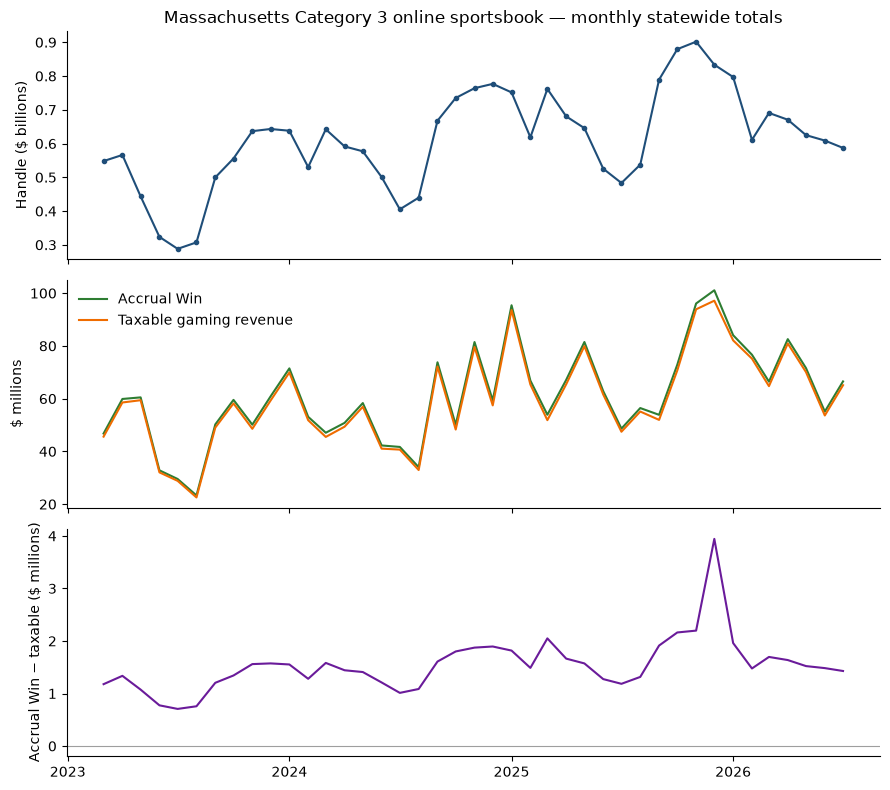

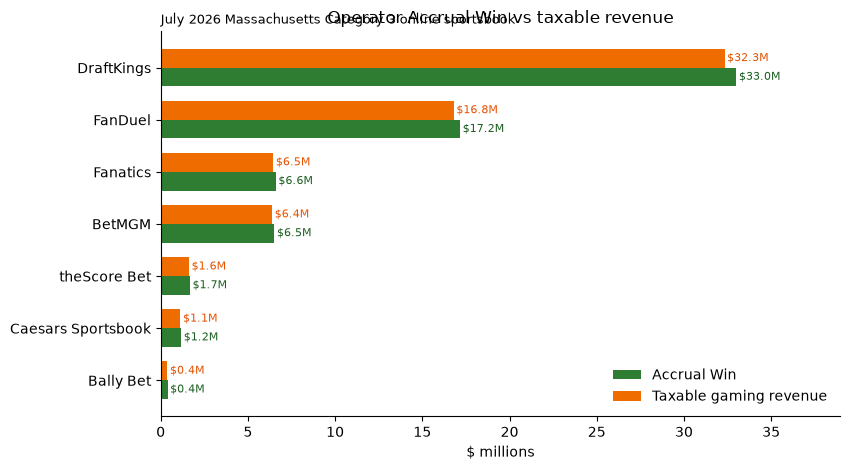

In [13]:
monthly = (
    prototype.groupby("period_start", as_index=False)
    .agg(
        handle=("wagers_settled", "sum"),
        accrual_win=("accrual_win", "sum"),
        taxable_revenue=("taxable_revenue", "sum"),
    )
)
monthly["period"] = pd.to_datetime(monthly["period_start"])
monthly["residual_m"] = (monthly["accrual_win"] - monthly["taxable_revenue"]) / 1e6

fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
axes[0].plot(monthly["period"], monthly["handle"] / 1e9, color="#1f4e79", marker="o", markersize=3)
axes[0].set_ylabel("Handle ($ billions)")
axes[0].set_title("Massachusetts Category 3 online sportsbook — monthly statewide totals")
axes[1].plot(monthly["period"], monthly["accrual_win"] / 1e6, color="#2e7d32", label="Accrual Win")
axes[1].plot(monthly["period"], monthly["taxable_revenue"] / 1e6, color="#ef6c00", label="Taxable gaming revenue")
axes[1].set_ylabel("$ millions")
axes[1].legend(frameon=False)
axes[2].plot(monthly["period"], monthly["residual_m"], color="#6a1b9a")
axes[2].axhline(0, color="#9e9e9e", linewidth=0.8)
axes[2].set_ylabel("Accrual Win − taxable ($ millions)")
locator = mdates.AutoDateLocator(minticks=4, maxticks=7)
# ~41 months needs a 12-month MONTHLY interval so AutoDateLocator can stay inside 4–7 ticks.
locator.intervald[mdates.MONTHLY] = [1, 2, 3, 4, 6, 12]
formatter = mdates.ConciseDateFormatter(locator)
for ax in axes:
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
fig.tight_layout()
plt.show()

july = prototype.loc[prototype["period_start"] == "2026-07-01"].sort_values("accrual_win")
fig, ax = plt.subplots(figsize=(8.6, 4.8))
y = range(len(july))
aw_m = july["accrual_win"] / 1e6
tr_m = july["taxable_revenue"] / 1e6
ax.barh([i - 0.18 for i in y], aw_m, height=0.36, color="#2e7d32", label="Accrual Win")
ax.barh([i + 0.18 for i in y], tr_m, height=0.36, color="#ef6c00", label="Taxable gaming revenue")
ax.set_yticks(list(y))
ax.set_yticklabels(july["operator"])
ax.set_xlabel("$ millions")
ax.set_title("Operator Accrual Win vs taxable revenue")
ax.text(0.0, 1.02, "July 2026 Massachusetts Category 3 online sportsbook", transform=ax.transAxes, fontsize=9)
for i, (aw, tr) in enumerate(zip(aw_m, tr_m, strict=True)):
    ax.text(aw + 0.15, i - 0.18, f"${aw:,.1f}M", va="center", fontsize=8, color="#1b5e20")
    ax.text(tr + 0.15, i + 0.18, f"${tr:,.1f}M", va="center", fontsize=8, color="#e65100")
ax.set_xlim(0, float(max(aw_m.max(), tr_m.max()) * 1.18))
ax.legend(frameon=False, loc="lower right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
plt.show()



## 15. Explicit design decision

Three alternatives were considered.

**Alternative A — keep storing only taxable revenue.** Rejected if Accrual Win is a distinct official column that the PDF already prints. It leaves `gross_revenue` empty and blocks any later hold or gross-win analysis that needs the published win figure.

**Alternative B — replace taxable revenue with Accrual Win.** Rejected. Taxable Gaming Revenue is the state-native tax base. Overwriting it would destroy the series that tax is computed from and would silently mix two economic stages.

**Alternative C — proposed.** Preserve `handle`, `taxable_revenue`, and `tax`. Populate the existing `gross_revenue` column with published Accrual Win. No schema change. The mapping is Massachusetts-specific and does not authorize treating MA Accrual Win as cross-state GGR.

If every validation in this notebook holds, Alternative C is the methodology recommendation.


## 16. Production implementation preview

**Do not implement in this notebook.**

Smallest future production change, after human review:

1. Extend the existing parsed money tuple so token 2 is retained as `accrual_win`.
2. Add `accrual_win` to operator dictionaries and to the Total Online control row.
3. Reconcile Accrual Win to the official total (suggested tolerance $0.01, same as taxable/tax).
4. Map `accrual_win` → existing `gross_revenue` in `build_normalized_rows`.
5. Preserve handle, taxable revenue, tax, labels, provenance, and the current retail/total exclusions.
6. Add focused March 2023 and July 2026 Accrual Win assertions next to the existing fixture tests.
7. Replay retained MA PDFs into a **candidate** database before any production replacement.

Do not add a new schema, a generic metric framework, a generalized state parser, or a new storage layer.


## 17. Final validation

The next cell restates the gates that must remain true after the walkthrough, re-hashes the database, and closes the read-only connection.


In [14]:
# Structural gates already asserted above; repeat the ones that define go/no-go.
assert len(pdfs) == 42
assert len(prototype) == 291
assert prototype["period_start"].nunique() == 41
assert ma["gross_revenue"].isna().all()
assert series_money_equal(merged["wagers_settled"], merged["handle"])
assert series_money_equal(merged["taxable_revenue_proto"], merged["taxable_revenue_db"])
assert series_money_equal(merged["tax_collected"], merged["tax"])
assert not breaches
assert "mode=ro" in DB_URI

DB_HASH_AFTER = sha256_file(DATABASE_PATH)
print("Database hash (after):", DB_HASH_AFTER)
assert DB_HASH_AFTER.lower() == DB_HASH_BEFORE.lower() == EXPECTED_DB_HASH.lower()
integrity_after = sqlite3.connect(DB_URI, uri=True).execute("PRAGMA integrity_check").fetchone()[0]
print("PRAGMA integrity_check after:", integrity_after)
assert integrity_after == "ok"
connection.close()

print("GO/NO-GO: READY FOR PRODUCTION IMPLEMENTATION REVIEW")
print("Mapping: Accrual Win → gross_revenue; handle/taxable/tax unchanged.")
print("Notebook completed offline; no SQLite writes.")



Database hash (after): 327799ca20d9a31fe664f489e5bbc98d930d0a3c08b786f849e4e746fdc3fdb6
PRAGMA integrity_check after: ok
GO/NO-GO: READY FOR PRODUCTION IMPLEMENTATION REVIEW
Mapping: Accrual Win → gross_revenue; handle/taxable/tax unchanged.
Notebook completed offline; no SQLite writes.


### Key findings

- Official MA Category 3 rows already print four money columns plus Hold %. The production parser currently drops Accrual Win.
- A minimal prototype that keeps token 2 parses all 42 retained PDFs: February 2023 is empty (pre-launch); 41 online months produce 291 operator rows.
- Those 291 rows match the current database on handle, taxable revenue, tax, operator, period, and source SHA-256. Only `gross_revenue` would become newly populated.
- Accrual Win is systematically larger than taxable revenue. The residual is useful to retain and is **not** proven here to be exclusively federal excise tax.
- Published Hold % tracks Accrual Win / handle, not taxable / handle.

### Exact mapping validated

| Official column | Existing / proposed field |
| --- | --- |
| Current & Future Wagers Settled | `handle` (already stored) |
| Accrual Win by Licensee | `gross_revenue` (proposed) |
| Taxable Gaming Revenue | `taxable_revenue` (already stored) |
| Tax Collected | `tax` (already stored) |

### Assumptions validated

- Two-line and inline layouts already used in production are sufficient for the retained archive.
- February 2023 is the only pre-launch empty month.
- Operator-sum vs Total Online stays within the stated tolerances (max handle $0.90, Accrual Win $0.00, taxable $0.01, tax $0.00).
- Enrichment does not require a schema change.

### Assumptions still uncertain

- Cash vs accrual timing of Accrual Win versus other states' GGR.
- Whether every `accrual_win - taxable_revenue` residual is federal excise tax (and only that).
- Promotion / free-play treatment inside Accrual Win.

### Point-in-time limitations

- MGC may update historical months.
- `retrieved_at_utc` is an ingestion clock, not a regulator publication clock.
- The current snapshot is one collection batch of one file per month. It cannot reconstruct earlier published values.

### Edge cases found

- March 2023 taxable operator-sum can sit one cent from the printed Total Online row (already known; within $0.01).
- One published Hold % differs from Accrual Win / handle by more than 0.01 pp: BetMGM, April 2024 (printed 6.22% vs calculated 6.186%; 0.034 pp). The row is displayed, not hidden. It does not break the Accrual Win mapping.
- Historical operator labels are unstable (`theScore Bet` vs `theScore Bet*`); joins must use stored labels, not a cleaned brand dimension.
- Tax is about 20% of taxable revenue on almost every row, but a few ratio exceptions exist. That diagnostic is not used to define `gross_revenue`.

### Production tests required

- March 2023 and July 2026 Accrual Win totals and DraftKings July 2026 Accrual Win.
- Negative-value preservation on token 2.
- Total Online Accrual Win reconcile.
- Replay of retained PDFs into a candidate database with unchanged handle/taxable/tax.

### Minimal proposed implementation

Retain money token 2 as `accrual_win` and map it to existing `gross_revenue`. Do not replace taxable revenue. Candidate replay before production replacement.

### Go/no-go recommendation

**READY FOR PRODUCTION IMPLEMENTATION REVIEW**
